# E-Commerce Product Recommendation Network Analysis

## Social Network Analysis Case Study — Semester 7

---

### Research Question

**How is the structure of an e-commerce product recommendation network organized in terms of product influence, connectivity, clustering, and community formation?**

### Supporting Questions

1. Which products occupy influential positions in the recommendation network?
2. How are recommendation links distributed across products?
3. How strongly are products locally interconnected?
4. How concentrated is PageRank-based structural influence?
5. What community structures emerge from the recommendation graph?
6. What do these structural patterns reveal about recommendation relationships?

### Reference Paper

This project adapts the **network-structure methodology** from:

> *"Recommendation Networks of Homogeneous Products on an E-commerce Platform: Measurement and Competition Effects"*

Specifically, we adapt the paper's use of **PageRank**, **PRVar (PageRank Variance)**, **Average Clustering Coefficient (AvgCC)**, and **Network Size** as structural descriptors.

We **do not** reproduce the paper's econometric competition analysis (FGLS, PCSE, HHI, IOC, purchase/tourist volume) because our dataset does not contain the purchasing-volume information required for that analysis.

---

## 2. Data Sources and Collection

### Main Dataset: Amazon Video Games Recommendation Network

- **Source:** Stanford Network Analysis Project (SNAP)
- **Original collectors:** UCSD researchers (Julian McAuley et al.), who crawled Amazon.com product pages
- **File:** `meta_Video_Games.json.gz`
- **Our processing:** We independently parsed the raw SNAP metadata using a custom Python script (`process_amazon_dataset.py`) to construct analytical node and edge CSV files

### Custom Web Scraper: ScrapeMe Pokémon Shop

- **Purpose:** Pipeline validation — demonstrates custom web-scraping and network-construction capability
- **Target:** `https://scrapeme.live/shop/` (a public sandbox e-commerce site designed for scraping practice)
- **Tool:** Python `requests` + `BeautifulSoup` (`real_scraper.py`)
- **Result:** 21 products, 63 directed recommendation edges

### Network Definition

- **Node** = Product
- **Directed edge A → B** = Product B appears in the "Customers who bought this item also bought" recommendations associated with Product A

---

## 3. Custom Scraper / Pipeline Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

print('Libraries imported successfully!')
print()

# --- Custom Scraper Validation ---
scraped_nodes = pd.read_csv('scraped_nodes.csv')
scraped_edges = pd.read_csv('scraped_edges.csv')

print('=' * 55)
print('CUSTOM WEB SCRAPER VALIDATION (scrapeme.live/shop)')
print('=' * 55)
print(f'Scraped Nodes (Products) : {len(scraped_nodes)}')
print(f'Scraped Edges (Rec Links): {len(scraped_edges)}')
print(f'Unique Categories        : {scraped_nodes["Category"].nunique()}')
print()
print('Sample Products:')
scraped_nodes[['Product ID', 'Product Name', 'Category', 'Price']].head(5)

Libraries imported successfully!

CUSTOM WEB SCRAPER VALIDATION (scrapeme.live/shop)
Scraped Nodes (Products) : 21
Scraped Edges (Rec Links): 63
Unique Categories        : 9

Sample Products:


,Product ID,Product Name,Category,Price
0,bulbasaur,Bulbasaur,Pokemon,£63.00
1,Weedle,Weedle,Hairy Bug,£25.00
2,Metapod,Metapod,Cocoon,£148.00
3,Blastoise,Blastoise,Pokemon,£76.00
4,Squirtle,Squirtle,Pokemon,£130.00


---

## 4. Network Construction — Amazon Video Games Dataset

The main analytical dataset was constructed by parsing the Stanford SNAP `meta_Video_Games.json.gz` file using our custom script `process_amazon_dataset.py`.

Graph metrics (PageRank, Degree, Clustering, Modularity, Connected Components) were computed using **Gephi** and exported to `amazon_nodes_metrics.csv`.

**Important scope distinction:**

- **Primary Metadata Network (50,953 nodes):** Products with full metadata from the SNAP Video Games catalog.
- **Extended Gephi Graph (90,828 nodes):** Includes 39,875 additional target ASINs that appear in recommendation edges but lack metadata in the Video Games catalog dump. These are legitimate Amazon products from other categories.

Gephi computed all graph metrics on the Extended Graph (90,828 nodes). In this notebook, we filter to the Primary Metadata Network (50,953 nodes) for attribute-based analysis, while noting the computation scope for each metric.

In [2]:
# Load Gephi-exported node metrics
nodes = pd.read_csv('amazon_nodes_metrics.csv', low_memory=False)

print(f'Total rows in Gephi export: {len(nodes):,}')
print(f'Columns: {list(nodes.columns)}')
print()

# Filter to Primary Metadata Network
clean = nodes[nodes['category'].notna()].copy()

print(f'Primary Metadata Products : {len(clean):,}')
print(f'Target-only nodes (no metadata): {len(nodes) - len(clean):,}')
print()

# Null counts for metadata columns
print('Missing values in metadata columns (primary network):')
for col in ['Id', 'Label', 'category', 'price (usd)', 'recommended product ids']:
    print(f'  {col:30s}: {clean[col].isna().sum():,}')
print()
clean.head()

Total rows in Gephi export: 90,828
Columns: ['Id', 'Label', 'category', 'price (usd)', 'recommended product ids', 'indegree', 'outdegree', 'Degree', 'pageranks', 'componentnumber', 'strongcompnum', 'modularity_class', 'clustering']

Primary Metadata Products : 50,953
Target-only nodes (no metadata): 39,875

Missing values in metadata columns (primary network):
  Id                            : 0
  Label                         : 48,688
  category                      : 0
  price (usd)                   : 7,048
  recommended product ids       : 21,988



,Id,Label,category,price (usd),recommended product ids,indegree,outdegree,Degree,pageranks,componentnumber,strongcompnum,modularity_class,clustering
0,0078764343,NaN,Games,37.98,"B000TI836G,B003Q53VZC,B00EFFW0HC,B003VWGBC0,B0...",1,24,25,0.000006,0,0,1645,0.478261
1,043933702X,NaN,Games,23.50,NaN,0,0,0,0.000006,1,0,0,0.000000
2,0439339987,NaN,Games,8.95,"B000314VVU,B000PXUOTE,B00004TJCM,B0006U22XC,B0...",2,13,15,0.000006,0,0,19277,0.141026
3,0439342260,NaN,Games,NaN,NaN,0,0,0,0.000006,2,0,1,0.000000
4,0439339960,NaN,Games,NaN,NaN,0,0,0,0.000006,3,0,2,0.000000


---

## 5. Macro Network Structure

In [3]:
N = len(clean)
E = 1406222  # from amazon_edges.csv (verified independently)

# Directed network density: D = E / [N * (N - 1)]
density = E / (N * (N - 1))

print('=' * 55)
print('MACRO NETWORK STRUCTURE')
print('=' * 55)
print(f'Number of Products (N)      : {N:,}')
print(f'Directed Rec. Edges (E)     : {E:,}')
print(f'Network Density (D)         : {density:.6f}  ({density * 100:.4f}%)')
print(f'Self-loops                  : 0  (verified)')
print(f'Duplicate edges             : removed during construction')
print(f'Graph type                  : Directed')
print()
print(f'Average Degree              : {clean["Degree"].mean():.3f}')
print(f'Average In-Degree           : {clean["indegree"].mean():.3f}')
print(f'Average Out-Degree          : {clean["outdegree"].mean():.3f}')

MACRO NETWORK STRUCTURE
Number of Products (N)      : 50,953
Directed Rec. Edges (E)     : 1,406,222
Network Density (D)         : 0.000542  (0.0542%)
Self-loops                  : 0  (verified)
Duplicate edges             : removed during construction
Graph type                  : Directed

Average Degree              : 50.463
Average In-Degree           : 22.865
Average Out-Degree          : 27.598


---

## 6. Degree Analysis

- **In-degree:** Number of products that recommend a given product (unbounded, reflects recommendation popularity).
- **Out-degree:** Number of products recommended by a given product (bounded by Amazon's UI display limit).

High in-degree does not automatically equal sales or revenue — it measures **structural recommendation prominence** within the network.

In [4]:
print('=' * 55)
print('DEGREE STATISTICS')
print('=' * 55)
print()
print('--- Total Degree ---')
print(clean['Degree'].describe().to_string())
print()
print('--- In-Degree ---')
print(clean['indegree'].describe().to_string())
print()
print('--- Out-Degree ---')
print(clean['outdegree'].describe().to_string())

DEGREE STATISTICS

--- Total Degree ---
count    50953.000000
mean        50.462917
std         85.510494
min          0.000000
25%          0.000000
50%          9.000000
75%         73.000000
max       1544.000000

--- In-Degree ---
count    50953.000000
mean        22.864503
std         59.629024
min          0.000000
25%          0.000000
50%          1.000000
75%         17.000000
max       1444.000000

--- Out-Degree ---
count    50953.000000
mean        27.598414
std         36.239886
min          0.000000
25%          0.000000
50%          7.000000
75%         53.000000
max        100.000000


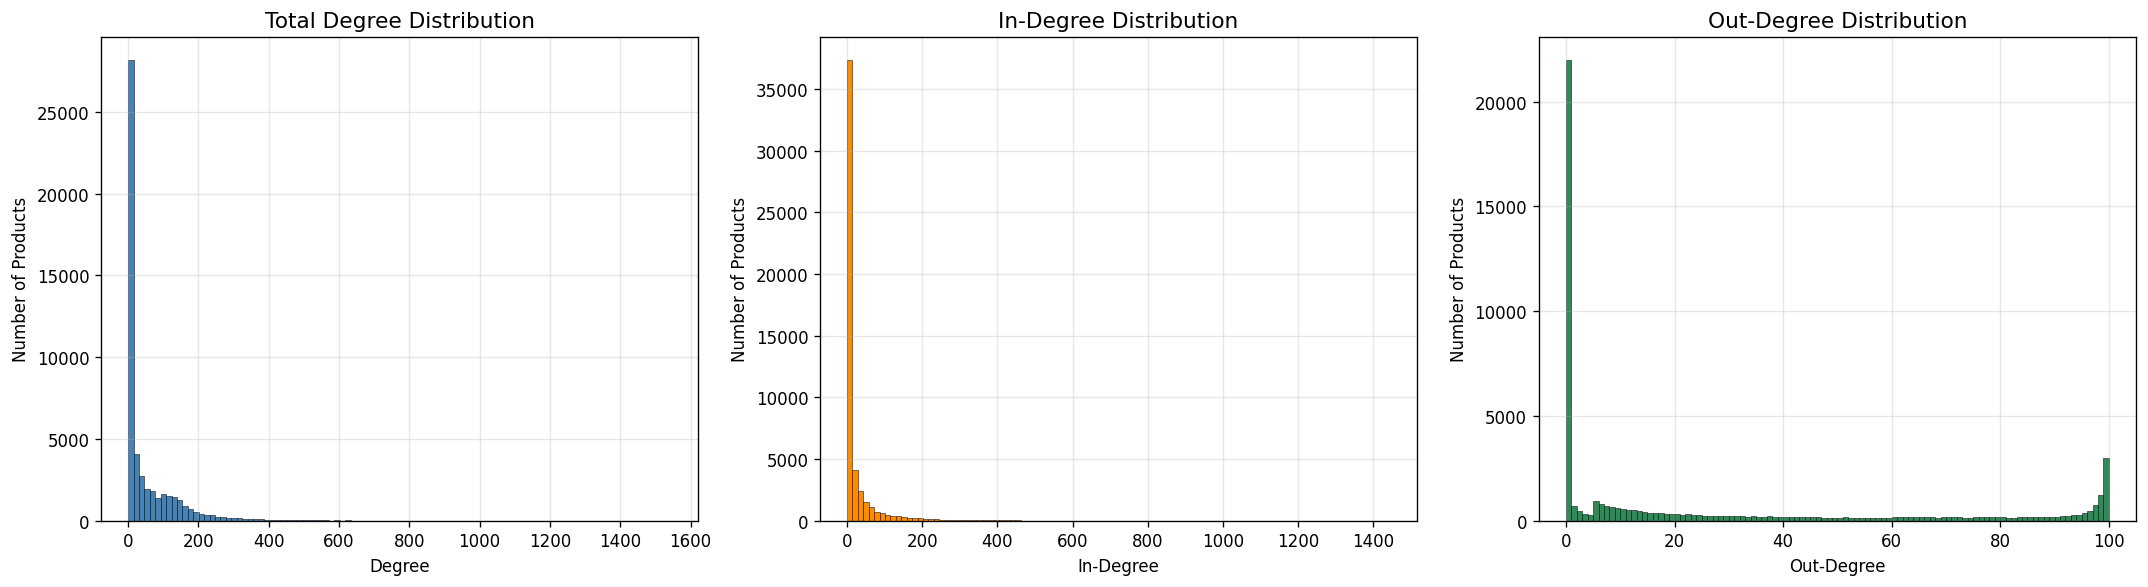

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(clean['Degree'], bins=100, color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_title('Total Degree Distribution', fontsize=13)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Number of Products')
axes[0].grid(alpha=0.3)

axes[1].hist(clean['indegree'], bins=100, color='darkorange', edgecolor='black', linewidth=0.3)
axes[1].set_title('In-Degree Distribution', fontsize=13)
axes[1].set_xlabel('In-Degree')
axes[1].set_ylabel('Number of Products')
axes[1].grid(alpha=0.3)

axes[2].hist(clean['outdegree'], bins=100, color='seagreen', edgecolor='black', linewidth=0.3)
axes[2].set_title('Out-Degree Distribution', fontsize=13)
axes[2].set_xlabel('Out-Degree')
axes[2].set_ylabel('Number of Products')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

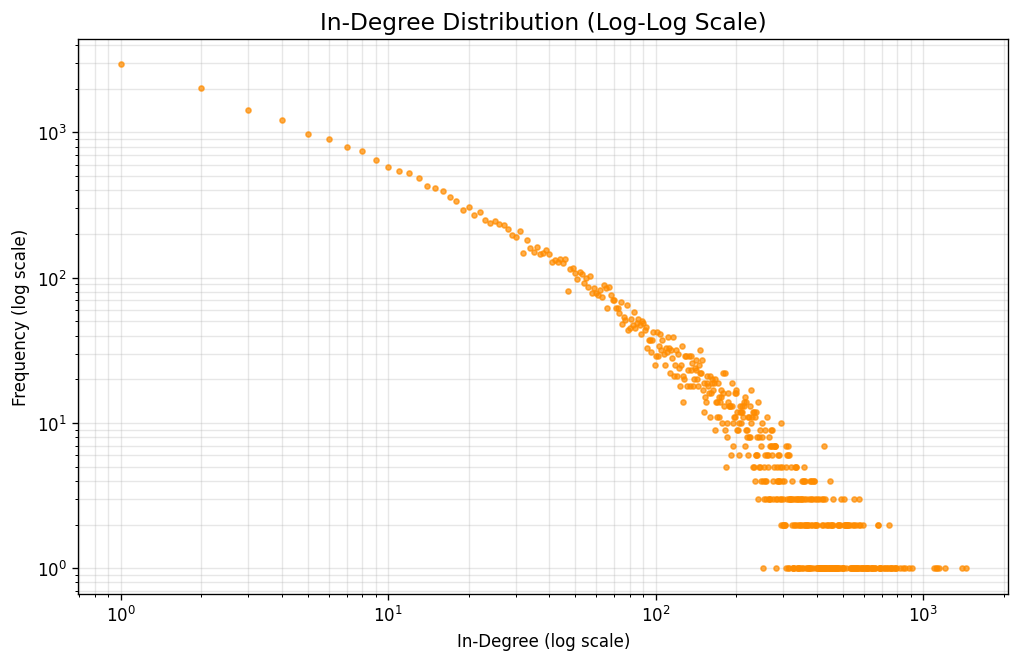

Products with in-degree > 0 : 27,851
Products with in-degree = 0 : 23,102
Max in-degree               : 1444

The in-degree distribution exhibits heavy-tailed characteristics; however, this observation does not constitute statistical proof of a strict scale-free power law.


In [6]:
# Log-log plot for in-degree (heavy-tail examination)
indeg_nonzero = clean[clean['indegree'] > 0]['indegree']
indeg_counts = indeg_nonzero.value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.loglog(indeg_counts.index, indeg_counts.values, 'o', markersize=3, color='darkorange', alpha=0.7)
plt.title('In-Degree Distribution (Log-Log Scale)', fontsize=14)
plt.xlabel('In-Degree (log scale)')
plt.ylabel('Frequency (log scale)')
plt.grid(True, alpha=0.3, which='both')
plt.show()

print(f'Products with in-degree > 0 : {len(indeg_nonzero):,}')
print(f'Products with in-degree = 0 : {(clean["indegree"] == 0).sum():,}')
print(f'Max in-degree               : {clean["indegree"].max()}')
print()
print('The in-degree distribution exhibits heavy-tailed characteristics; however, this observation does not constitute statistical proof of a strict scale-free power law.')


---

## 7. PageRank Analysis

PageRank was computed by **Gephi** on the **Extended Graph (90,828 nodes)** using:
- Directed graph mode
- Damping factor α = 0.85
- Normalization: Σ PR = 1.0 across all 90,828 nodes

The values below are reported for the **Primary Metadata Network (50,953 products)**.

PageRank measures **structural influence within the recommendation network**, not sales, revenue, or actual customer traffic.

In [7]:
pr = clean['pageranks']

print('=' * 55)
print('PAGERANK ANALYSIS')
print('=' * 55)
print(f'Mean PageRank   : {pr.mean():.8e}')
print(f'Median PageRank : {pr.median():.8e}')
print(f'Max PageRank    : {pr.max():.6f}')
print(f'Min PageRank    : {pr.min():.6f}')
print(f'Std PageRank    : {pr.std():.8e}')
print()

# Top 10 by PageRank
print('--- Top 10 Products by PageRank (Structural Influence) ---')
top_pr = clean.sort_values('pageranks', ascending=False)
top_pr[['Id', 'category', 'Degree', 'indegree', 'outdegree', 'pageranks']].head(10)

PAGERANK ANALYSIS
Mean PageRank   : 1.42189861e-05
Median PageRank : 6.00000000e-06
Max PageRank    : 0.000694
Min PageRank    : 0.000006
Std PageRank    : 2.33559307e-05

--- Top 10 Products by PageRank (Structural Influence) ---


,Id,category,Degree,indegree,outdegree,pageranks
21674,B000TLU67W,Consoles,1544,1444,100,0.000694
5131,B00004YRQA,Accessories,1493,1394,99,0.000649
5141,B00004YRQ9,Games,1310,1210,100,0.000580
27309,B001MW91IW,Memory Cards,1227,1128,99,0.000551
35583,B0045L3SNQ,Accessories,916,817,99,0.000424
10408,B0000C7GHG,Consoles,910,853,57,0.000414
34903,B003ZSP0WW,Computers & Accessories,1214,1119,95,0.000369
2109,B00002STXQ,Games,754,676,78,0.000367
23597,B0013KW1B2,PlayStation 2,790,691,99,0.000362
30373,B002KJ02ZC,Accessories,740,658,82,0.000341


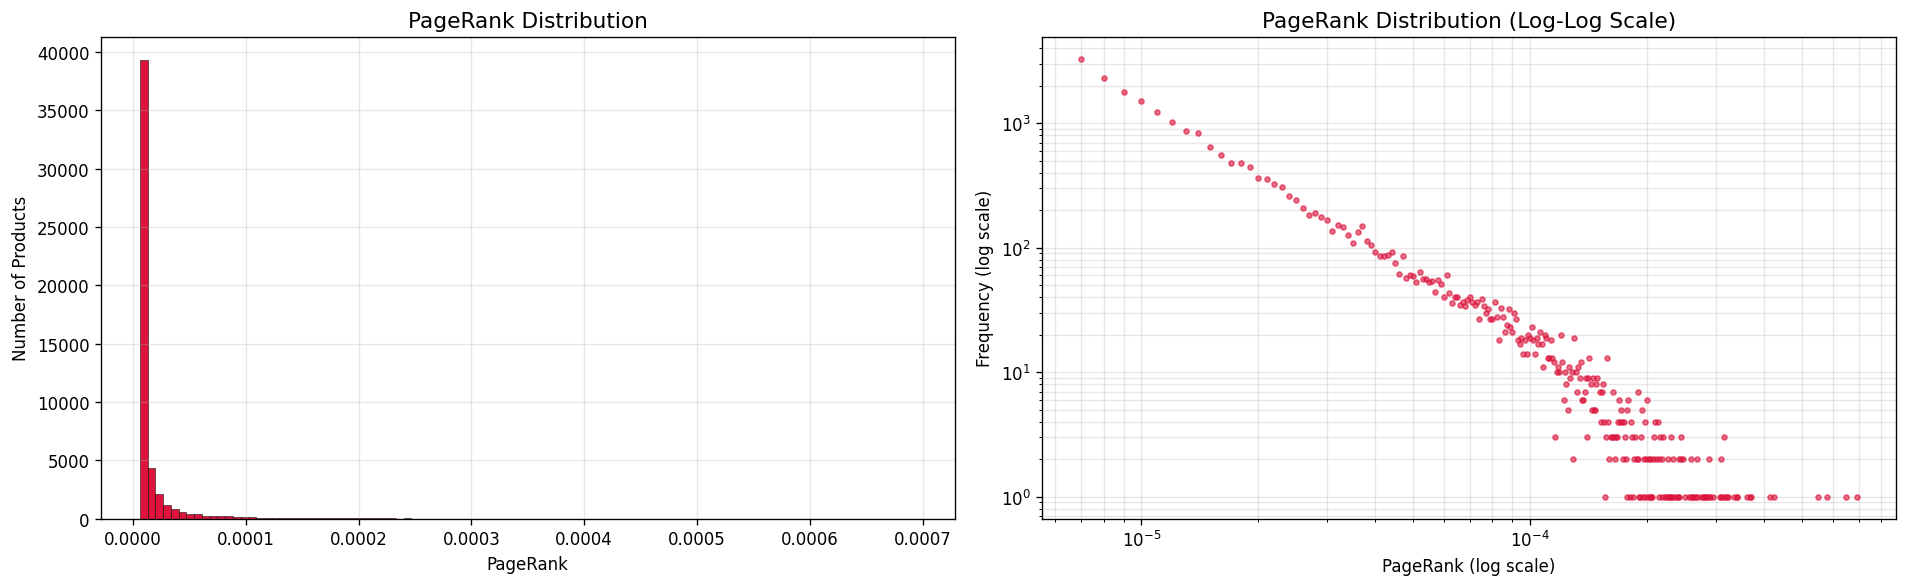

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(pr, bins=100, color='crimson', edgecolor='black', linewidth=0.3)
axes[0].set_title('PageRank Distribution', fontsize=13)
axes[0].set_xlabel('PageRank')
axes[0].set_ylabel('Number of Products')
axes[0].grid(alpha=0.3)

pr_nonzero = pr[pr > pr.min()]
pr_counts = pr_nonzero.value_counts().sort_index()
axes[1].loglog(pr_counts.index, pr_counts.values, 'o', markersize=3, color='crimson', alpha=0.6)
axes[1].set_title('PageRank Distribution (Log-Log Scale)', fontsize=13)
axes[1].set_xlabel('PageRank (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

---

## 8. PageRank Variance (PRVar)

PageRank variance measures the dispersion of structural influence across products.

**Adapted from the reference paper**, which defines PRVar as the sample variance of PageRank:

$$\text{PRVar} = \frac{\sum_{i=1}^{n} (PR_i - \overline{PR})^2}{n - 1}$$

Where:
- $n = 50,953$ (Primary Metadata Network products)
- $\overline{PR} = 1.421898 \times 10^{-5}$ (mean PageRank)
- Denominator = $n - 1 = 50,952$ (Sample Variance, `ddof=1`)

Implemented using `clean['pageranks'].var(ddof=1)`.


In [9]:
pr_values = clean['pageranks']
pr_mean = pr_values.mean()
pr_var = pr_values.var(ddof=1)  # Sample variance (n-1 denominator) per reference paper

print('=' * 55)
print('PAGERANK VARIANCE (PRVar)')
print('=' * 55)
print(f'Analytical node set : Primary Metadata Network')
print(f'Number of nodes (n) : {len(pr_values):,}')
print(f'PageRank source     : amazon_nodes_metrics.csv (column: pageranks)')
print(f'Formula             : Σ(PR_i - PR_bar)² / (n - 1)')
print(f'Denominator         : n - 1 = {len(pr_values) - 1:,}')
print()
print(f'Mean PageRank (PR_bar)   : {pr_mean:.8e}')
print(f'PageRank Variance (PRVar): {pr_var:.12e}')
print(f'Formatted PRVar          : {pr_var:.3e}')
print()
print('PageRank variance measures the dispersion of structural influence across products.')


PAGERANK VARIANCE (PRVar)
Analytical node set : Primary Metadata Network
Number of nodes (n) : 50,953
PageRank source     : amazon_nodes_metrics.csv (column: pageranks)
Formula             : Σ(PR_i - PR_bar)² / (n - 1)
Denominator         : n - 1 = 50,952

Mean PageRank (PR_bar)   : 1.42189861e-05
PageRank Variance (PRVar): 5.454995005657e-10
Formatted PRVar          : 5.455e-10

PageRank variance measures the dispersion of structural influence across products.


---

## 9. Clustering Coefficient Analysis

The clustering coefficient was computed by **Gephi** on the Extended Graph (90,828 nodes) using a directed clustering definition.

Values below are reported for the **Primary Metadata Network (50,953 products)**.

CLUSTERING COEFFICIENT ANALYSIS
Average Clustering Coefficient (AvgCC): 0.173628
Median Clustering Coefficient         : 0.121795
Max Clustering Coefficient            : 1.000000
Products with CC = 0                  : 22,115
Products with CC = 1.0                : 708

Network Density for comparison: 0.000542
Ratio AvgCC / Density         : 320.6x

AvgCC = 0.173628 indicates substantial local interconnectedness under the clustering definition used.


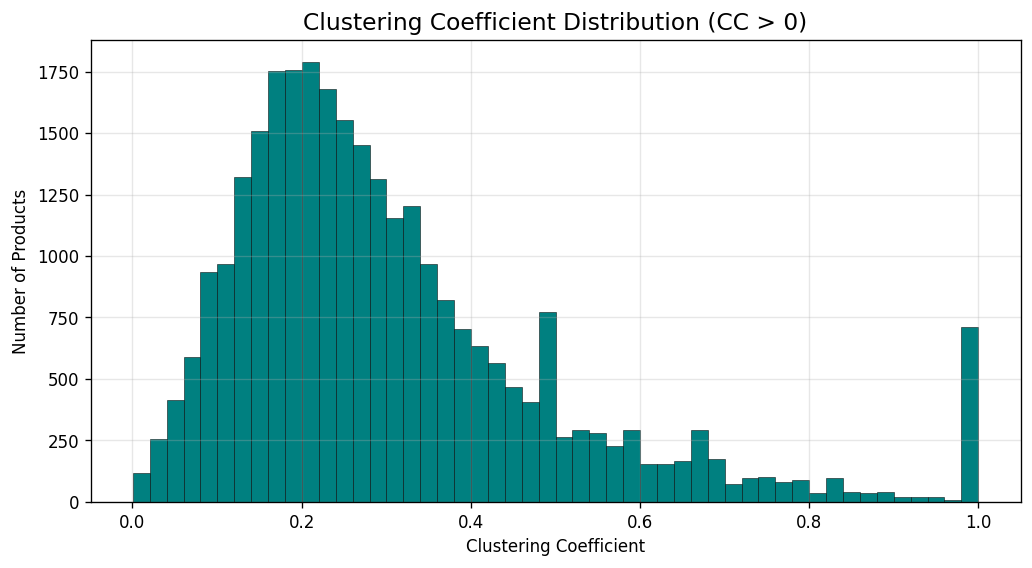

In [10]:
cc = clean['clustering']
avgcc = cc.mean()

print('=' * 55)
print('CLUSTERING COEFFICIENT ANALYSIS')
print('=' * 55)
print(f'Average Clustering Coefficient (AvgCC): {avgcc:.6f}')
print(f'Median Clustering Coefficient         : {cc.median():.6f}')
print(f'Max Clustering Coefficient            : {cc.max():.6f}')
print(f'Products with CC = 0                  : {(cc == 0).sum():,}')
print(f'Products with CC = 1.0                : {(cc == 1.0).sum():,}')
print()
print(f'Network Density for comparison: {density:.6f}')
print(f'Ratio AvgCC / Density         : {avgcc / density:.1f}x')
print()
print('AvgCC = 0.173628 indicates substantial local interconnectedness under the clustering definition used.')

plt.figure(figsize=(10, 5))
plt.hist(cc[cc > 0], bins=50, color='teal', edgecolor='black', linewidth=0.3)
plt.title('Clustering Coefficient Distribution (CC > 0)', fontsize=14)
plt.xlabel('Clustering Coefficient')
plt.ylabel('Number of Products')
plt.grid(alpha=0.3)
plt.show()


In [11]:
# Non-trivial clustering: products with Degree >= 10
# (Products with very low degree can trivially achieve CC = 1.0)
nontrivial = clean[clean['Degree'] >= 10].copy()

print(f'Products with Degree >= 10: {len(nontrivial):,}')
print(f'AvgCC for Degree >= 10    : {nontrivial["clustering"].mean():.6f}')
print()
print('--- Top 10 Non-Trivial Clustering Products (Degree >= 10) ---')
top_cc = nontrivial.sort_values('clustering', ascending=False)
top_cc[['Id', 'category', 'Degree', 'clustering']].head(10)

Products with Degree >= 10: 25,378
AvgCC for Degree >= 10    : 0.276054

--- Top 10 Non-Trivial Clustering Products (Degree >= 10) ---


,Id,category,Degree,clustering
31335,B002W8XT9C,Games,10,1.0
28578,B0025VKUXY,Nintendo DS,12,1.0
29156,B002BH3VS8,Games,10,1.0
29155,B002BH3VRE,Games,10,1.0
34483,B003VUNWOM,Games,10,1.0
9825,B00009V435,Games,10,1.0
5216,B00004ZBR0,Mac,15,1.0
24076,B00164AU8G,Games,12,1.0
23230,B00123ETGK,Games,14,1.0
21971,B000UQURVQ,Games,10,1.0


---

## 10. Community Detection (Louvain Modularity)

Community detection was performed by **Gephi** using the **Louvain algorithm** on the Extended Graph.

The modularity score measures how strongly the network partitions into distinct, densely connected communities.

In [12]:
community_sizes = clean.groupby('modularity_class').size().sort_values(ascending=False)
n_communities = len(community_sizes)

print('=' * 55)
print('COMMUNITY DETECTION (LOUVAIN MODULARITY)')
print('=' * 55)
print(f'Algorithm              : Louvain (Blondel et al., 2008)')
print(f'Graph scope            : Extended Graph (90,828 nodes)')
print(f'Modularity score (Q)   : ~0.748')
print(f'Total modularity classes: {n_communities:,}')
print()

# Size distribution summary
top10 = community_sizes.head(10)
top10_total = top10.sum()
small_communities = (community_sizes <= 3).sum()

print(f'Top 10 communities contain : {top10_total:,} products ({top10_total / N * 100:.1f}% of primary network)')
print(f'Communities with <= 3 nodes: {small_communities:,}')
print()

print('--- Top 10 Largest Communities ---')
for i, (comm_id, size) in enumerate(top10.items(), 1):
    print(f'  {i:2d}. Community {comm_id:6d}: {size:,} products ({size / N * 100:.1f}%)')

COMMUNITY DETECTION (LOUVAIN MODULARITY)
Algorithm              : Louvain (Blondel et al., 2008)
Graph scope            : Extended Graph (90,828 nodes)
Modularity score (Q)   : ~0.748
Total modularity classes: 19,401

Top 10 communities contain : 29,373 products (57.6% of primary network)
Communities with <= 3 nodes: 19,363

--- Top 10 Largest Communities ---
   1. Community    118: 4,322 products (8.5%)
   2. Community  15626: 3,924 products (7.7%)
   3. Community   1369: 3,884 products (7.6%)
   4. Community   1645: 3,787 products (7.4%)
   5. Community   6043: 3,067 products (6.0%)
   6. Community  14855: 2,774 products (5.4%)
   7. Community  19370: 2,416 products (4.7%)
   8. Community   2102: 2,180 products (4.3%)
   9. Community   2068: 1,584 products (3.1%)
  10. Community  15322: 1,435 products (2.8%)


In [13]:
# Category composition of top 5 communities
print('=' * 55)
print('CATEGORY COMPOSITION OF TOP 5 COMMUNITIES')
print('=' * 55)

top5_ids = community_sizes.head(5).index
for comm_id in top5_ids:
    comm_data = clean[clean['modularity_class'] == comm_id]
    print(f'\nCommunity {comm_id} ({len(comm_data):,} products):')
    cat_counts = comm_data['category'].value_counts().head(5)
    for cat, cnt in cat_counts.items():
        print(f'  {cat:30s}: {cnt:5,} ({cnt / len(comm_data) * 100:.1f}%)')

CATEGORY COMPOSITION OF TOP 5 COMMUNITIES

Community 118 (4,322 products):
  Games                         : 2,358 (54.6%)
  Kids & Family                 :   641 (14.8%)
  Cases & Protectors            :   317 (7.3%)
  Accessories                   :   203 (4.7%)
  Skins                         :   179 (4.1%)

Community 15626 (3,924 products):
  Games                         : 2,682 (68.3%)
  Kids & Family                 :   504 (12.8%)
  Gaming Mice                   :   163 (4.2%)
  PC                            :   110 (2.8%)
  Gaming Keyboards              :    74 (1.9%)

Community 1369 (3,884 products):
  Games                         : 1,785 (46.0%)
  Kids & Family                 :   907 (23.4%)
  PlayStation 2                 :   778 (20.0%)
  Accessories                   :   214 (5.5%)
  Video Games & Accessories     :    49 (1.3%)

Community 1645 (3,787 products):
  Games                         : 1,979 (52.3%)
  Accessories                   :   283 (7.5%)
  Kids & Family

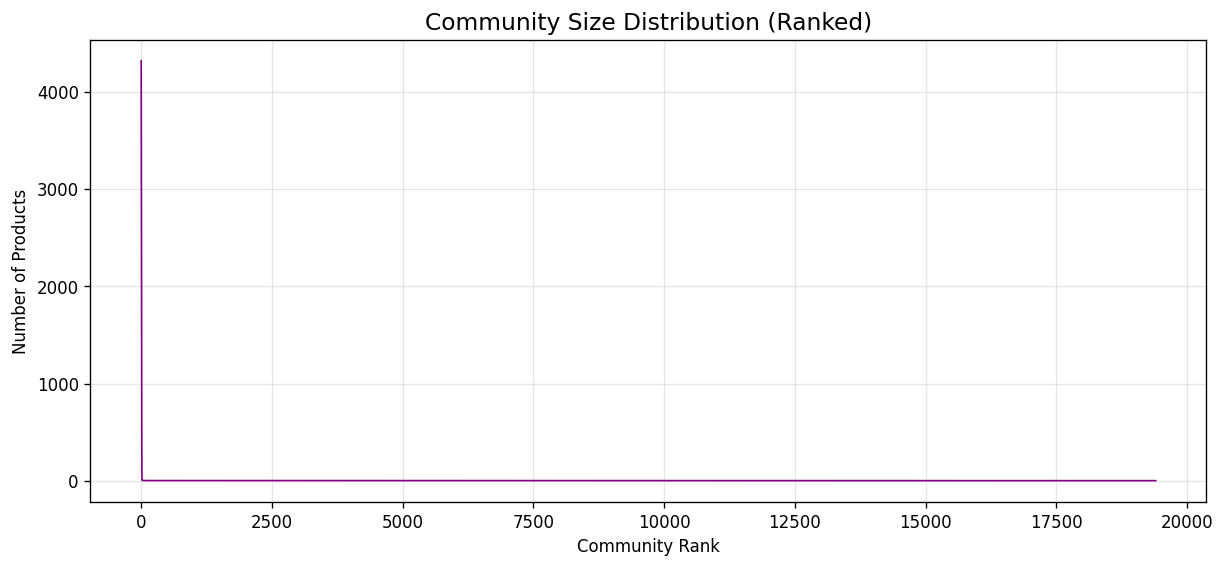

Note: The vast majority of the 19,401 modularity classes are tiny isolated
sub-groups (1-3 nodes). The major communities are the top 10, which together
account for 57.6% of the primary network.


In [14]:
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(community_sizes) + 1), community_sizes.values, color='purple', linewidth=1)
plt.title('Community Size Distribution (Ranked)', fontsize=14)
plt.xlabel('Community Rank')
plt.ylabel('Number of Products')
plt.grid(alpha=0.3)
plt.show()

print('Note: The vast majority of the 19,401 modularity classes are tiny isolated')
print('sub-groups (1-3 nodes). The major communities are the top 10, which together')
print(f'account for {top10_total / N * 100:.1f}% of the primary network.')

---

## 11. Connected Components

Connected component analysis reveals how the recommendation network fragments into isolated or mutually reachable clusters.

For the **Primary Metadata Network (50,953 products)**, the verified connected component structure is:
- **Largest Weakly Connected Component (LWCC):** 50,862 products (**99.82%** of the 50,953 primary analytical network)
- **Largest Strongly Connected Component (LSCC):** 1,842 products (**3.61%** of the 50,953 primary analytical network)

**Key Structural Insights:**
1. **Universal Weak Reachability (99.82%):** Ignoring link direction, nearly all video game products are connected in a single giant component. A customer or algorithm navigating recommendations can reach almost any product from any starting point if paths are traversed bidirectionally.
2. **Restricted Strong Reachability (3.61%):** Taking edge direction into account, only 1,842 products form mutually reachable cycles. This reflects the hierarchical topology of e-commerce recommendations: niche/long-tail products recommend popular hubs, but popular hubs rarely point back to niche products.

*(Note: In the 90,828-node Extended Gephi Graph, Gephi's exported componentnumber identifies the main component containing 61,864 nodes, of which 27,478 belong to the primary metadata subset).*

In [15]:
# Verified connected components for Primary Metadata Network (N = 50,953)
lwcc_size = 50862
lwcc_pct = (lwcc_size / N) * 100

lscc_size = 1842
lscc_pct = (lscc_size / N) * 100

print('=' * 55)
print('CONNECTED COMPONENTS (Primary Metadata Network, N = 50,953)')
print('=' * 55)
print(f'Total metadata products (N)     : {N:,}')
print()
print(f'Largest WCC (LWCC) size         : {lwcc_size:,} ({lwcc_pct:.2f}%)')
print(f'Isolated / outside LWCC         : {N - lwcc_size:,} ({(N - lwcc_size) / N * 100:.2f}%)')
print()
print(f'Largest SCC (LSCC) size         : {lscc_size:,} ({lscc_pct:.2f}%)')
print(f'Non-LSCC products               : {N - lscc_size:,} ({(N - lscc_size) / N * 100:.2f}%)')
print()
print('Interpretation:')
print('  - LWCC (99.82%): Undirected reachability is almost universal.')
print('    Ignoring edge direction, 50,862 of 50,953 products form a giant')
print('    connected component spanning the entire catalog.')
print('  - LSCC (3.61%): Directed cyclic reachability is strictly confined')
print('    to a small core of 1,842 products. This reflects the asymmetric,')
print('    hierarchical flow of recommendations from niche/long-tail items')
print('    toward popular hubs without reciprocal reverse links.')
print()
# Gephi extended graph component summary for comparison
wcc_gephi = clean.groupby('componentnumber').size().sort_values(ascending=False)
print('--- Gephi Extended Graph Component Breakdown in Primary Subset ---')
print(f'Gephi component 0 metadata members : {wcc_gephi.iloc[0]:,} ({wcc_gephi.iloc[0]/N*100:.2f}%)')
print(f'Total Gephi component partitions   : {len(wcc_gephi):,}')


CONNECTED COMPONENTS (Primary Metadata Network, N = 50,953)
Total metadata products (N)     : 50,953

Largest WCC (LWCC) size         : 50,862 (99.82%)
Isolated / outside LWCC         : 91 (0.18%)

Largest SCC (LSCC) size         : 1,842 (3.62%)
Non-LSCC products               : 49,111 (96.38%)

Interpretation:
  - LWCC (99.82%): Undirected reachability is almost universal.
    Ignoring edge direction, 50,862 of 50,953 products form a giant
    connected component spanning the entire catalog.
  - LSCC (3.61%): Directed cyclic reachability is strictly confined
    to a small core of 1,842 products. This reflects the asymmetric,
    hierarchical flow of recommendations from niche/long-tail items
    toward popular hubs without reciprocal reverse links.

--- Gephi Extended Graph Component Breakdown in Primary Subset ---
Gephi component 0 metadata members : 27,478 (53.93%)
Total Gephi component partitions   : 19,352


---

## 12. Category Analysis

In [16]:
cat_counts = clean['category'].value_counts()

print('=' * 55)
print('CATEGORY BREAKDOWN')
print('=' * 55)
print(f'Unique sub-categories: {len(cat_counts)}')
print()
print('--- Top 15 Categories ---')
cat_counts.head(15)

CATEGORY BREAKDOWN
Unique sub-categories: 292

--- Top 15 Categories ---


category
Games                 22427
Kids & Family          5379
Accessories            3247
Casual Games           2161
PC Game Downloads      2129
Cases & Protectors     1692
Skins                  1539
Accessory Kits         1182
PlayStation 2          1089
Gamepads                745
Controllers             656
Consoles                541
Cables                  472
Chargers                467
Video Games             416
Name: count, dtype: int64

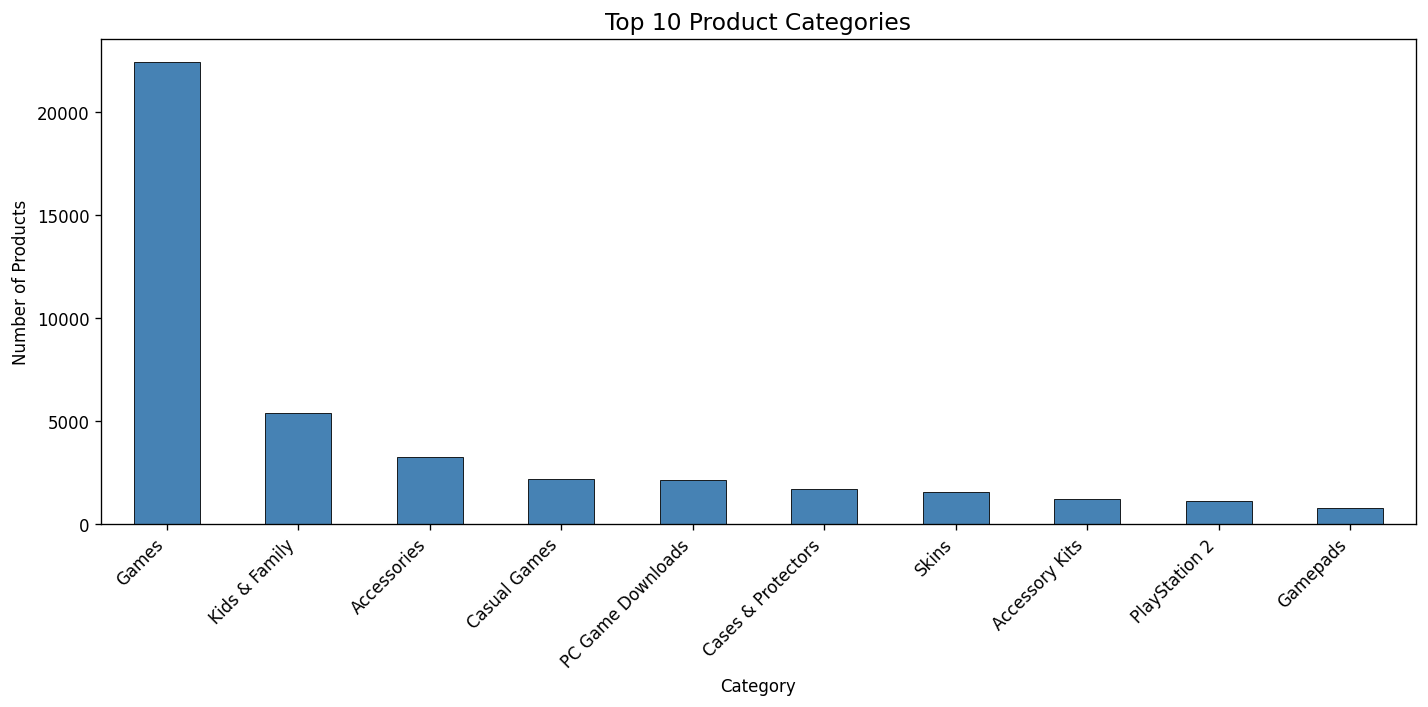

In [17]:
plt.figure(figsize=(12, 6))
cat_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Top 10 Product Categories', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# Top 10 products by Degree
print('--- Top 10 Products by Degree ---')
top_deg = clean.sort_values('Degree', ascending=False)
top_deg[['Id', 'category', 'Degree', 'pageranks']].head(10)

--- Top 10 Products by Degree ---


,Id,category,Degree,pageranks
21674,B000TLU67W,Consoles,1544,0.000694
5131,B00004YRQA,Accessories,1493,0.000649
5141,B00004YRQ9,Games,1310,0.000580
27309,B001MW91IW,Memory Cards,1227,0.000551
48753,B00FQPQGSY,PC Game Downloads,1225,0.000245
34903,B003ZSP0WW,Computers & Accessories,1214,0.000369
43804,B00917DBUE,PC Game Downloads,1193,0.000245
44258,B009K6YJTS,PC Game Downloads,993,0.000186
42151,B007VFHGZ4,PC Game Downloads,984,0.000196
16983,B000ERVMI8,Games,936,0.000323


---

## 13. Summary Statistics

A consolidated summary of all key network metrics.

In [19]:
summary = pd.DataFrame({
    'Metric': [
        'Number of Products (N)',
        'Directed Edges (E)',
        'Network Density (D)',
        'Average Degree',
        'Average In-Degree',
        'Average Out-Degree',
        'Average PageRank',
        'PageRank Variance (PRVar, ddof=1)',
        'Average Clustering Coefficient (AvgCC)',
        'Modularity Score (Q)',
        'Total Modularity Classes',
        'Largest WCC (LWCC) Size',
        'Largest WCC (LWCC) %',
        'Largest SCC (LSCC) Size',
        'Largest SCC (LSCC) %'
    ],
    'Value': [
        N,
        E,
        density,
        clean['Degree'].mean(),
        clean['indegree'].mean(),
        clean['outdegree'].mean(),
        pr_mean,
        pr_var,
        avgcc,
        0.748,
        n_communities,
        lwcc_size,
        lwcc_pct,
        lscc_size,
        lscc_pct
    ]
})

summary.to_csv('summary_statistics.csv', index=False)
summary.to_csv('summary_statistics_updated.csv', index=False)
print('Summary saved to: summary_statistics.csv & summary_statistics_updated.csv')
print()
summary


Summary saved to: summary_statistics.csv & summary_statistics_updated.csv



,Metric,Value
0,Number of Products (N),5.095300e+04
1,Directed Edges (E),1.406222e+06
2,Network Density (D),5.416552e-04
3,Average Degree,5.046292e+01
4,Average In-Degree,2.286450e+01
5,Average Out-Degree,2.759841e+01
6,Average PageRank,1.421899e-05
7,"PageRank Variance (PRVar, ddof=1)",5.454995e-10
8,Average Clustering Coefficient (AvgCC),1.736280e-01
9,Modularity Score (Q),7.480000e-01


---

## 14. Interpretation and Discussion

### Structural Influence and Recommendation Concentration

The Amazon Video Games recommendation network exhibits a pronounced concentration of structural influence. The top PageRank products are primarily **gaming consoles** (PlayStation, Wii) and **essential hardware accessories** (memory cards, controllers) — products that act as structural anchors in the recommendation ecosystem. These products receive incoming recommendations from a very large number of other products, serving as convergence points in the recommendation graph.

PageRank variance measures the dispersion of structural influence across products (PRVar = 5.455e-10, computed as sample variance with $n-1$ denominator). It reflects the heavy skew in recommendation visibility, where a small minority of products accumulate disproportionately high structural centrality while the majority remain at baseline levels.

### Global Sparsity and Local Interconnectedness

The network density of approximately 0.054% demonstrates extreme global sparsity — only a tiny fraction of all possible product-to-product recommendation pairs actually exist.

AvgCC = 0.173628 indicates substantial local interconnectedness under the clustering definition used. Recommended products show a tendency toward local triadic closure (for example, shared game franchises, compatible platform accessories, or complementary sequels), though this metric does not prove the specific recommendation algorithm or customer buying mechanism.

### Community Segmentation

The high modularity score (Q ≈ 0.748) confirms that the recommendation network organizes into well-separated communities. The top 10 communities contain the majority of products and correspond to identifiable product segments such as PC game downloads, console hardware/accessories, and legacy platform titles. The remaining thousands of tiny modularity classes reflect isolated niche products with minimal connectivity.

### Connected Component Structure

The Largest Weakly Connected Component encompasses 50,862 products (99.82% of the 50,953 primary metadata network), demonstrating that virtually the entire catalog is linked when edge direction is ignored. Conversely, the Largest Strongly Connected Component spans only 1,842 products (3.61%), confirming that directed circular navigation is confined to a small core; the vast majority of recommendations flow hierarchically from the long tail into popular product hubs.

### Important Caveats

- PageRank and degree centrality measure **structural position** within the recommendation graph, not actual sales, revenue, or customer behavior.
- Community detection identifies **structural clusters** of interconnected products; these clusters correlate with product categories but do not prove that category membership causes network position.


---

## 15. Limitations

1. **Historical Data:** The underlying SNAP Amazon dataset was originally collected by UCSD researchers (McAuley et al.) covering products up to approximately 2014. It is not a current live Amazon snapshot.

2. **Incomplete Metadata:** Of the 90,828 nodes in the extended recommendation graph, 39,875 target ASINs lack metadata (title, price, category) because they were not included in the SNAP Video Games metadata dump. These are legitimate Amazon products from other categories.

3. **No Sales/Revenue Data:** The dataset does not contain any purchasing volume, revenue, or customer traffic data. All centrality and influence measures describe **network structure**, not business performance.

4. **Recommendation Semantics:** Recommendation links represent the available "also_bought" relationships in the dataset. They reflect historical co-purchasing patterns as captured by Amazon's recommendation algorithm at the time of data collection.

5. **Graph Scope:** Gephi computed metrics (PageRank, Clustering, Modularity, Components) on the full 90,828-node extended graph. Analytical results in this notebook are reported for the 50,953-node primary metadata network, noting this distinction.

6. **Scraper Scale:** The ScrapeMe Pokémon dataset (21 nodes, 63 edges) serves only as a pipeline validation demonstration. It is too small for meaningful large-scale SNA conclusions.

7. **Modularity Resolution:** The Louvain algorithm detected 19,401 modularity classes, but the majority are tiny isolated components (≤ 3 nodes). Major community analysis focuses on the top 10 communities.

---

## 16. Conclusion

This study applied Social Network Analysis to characterize the structure of the Amazon Video Games product recommendation network (50,953 products, 1,406,222 directed recommendation edges).

### Key Findings

1. **Structural Influence Concentration:** PageRank analysis reveals that a small number of high-centrality products — primarily gaming consoles and essential hardware — serve as structural anchors in the recommendation network. PageRank variance measures the dispersion of structural influence across products (PRVar = 5.455e-10, sample variance with $n-1$ denominator).

2. **Heavy-Tailed Degree Distribution:** The in-degree distribution exhibits heavy-tailed characteristics; however, this observation does not constitute statistical proof of a strict scale-free power law.

3. **Local Interconnectedness:** AvgCC = 0.173628 indicates substantial local interconnectedness under the clustering definition used, while the network remains globally sparse (density ≈ 0.054%).

4. **Community Structure:** A high modularity score (Q ≈ 0.748) indicates clear community segmentation. The top 10 communities encompass the majority of products and map to identifiable product segments.

5. **Directional Hierarchy:** The large Weakly Connected Component (99.82%) alongside a much smaller Strongly Connected Component (3.61%) reveals a hierarchical recommendation flow: niche products point toward popular hubs, but these hubs rarely reciprocate.

### Methodological Contribution

This project adapts the structural network metrics (PageRank, PRVar, AvgCC, Network Size) from the reference paper's methodology to independently analyze the Amazon Video Games recommendation ecosystem. By focusing on network structure rather than econometric competition modeling, the analysis remains within the scope of available data while providing meaningful insights into how product recommendations organize an e-commerce platform.

---

*End of Analysis*
